## **ПОДГОТОВКА**

- #### population_encode - яркость пикселя превращается в активность группы нейронов. Каждый пиксель кодируется 12 нейронами. Гауссова функция активации:
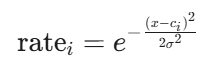

- #### generate_poisson_spikes - тут идет расчет вероятности спайка и создаются спайки. Получается дискретный выход 0 или 1.

- #### run_lif_batch - решение о классификации.

In [10]:
import torch
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

POP_NEURONS = 12
INPUT_NEURONS = 784 * POP_NEURONS
OUTPUT_NEURONS = 10
SIM_TIME = 50
EPOCHS = 5

def population_encode(images):
    batch_size = images.shape[0]
    img_flat = (1.0 - images.view(batch_size, -1)).to(device)
    centers = torch.linspace(0, 1, POP_NEURONS, device=device)
    sigma = 0.25
    diff = img_flat.unsqueeze(-1) - centers.view(1, 1, -1)
    rates = torch.exp(-(diff ** 2) / (2 * sigma ** 2))
    return rates.view(batch_size, -1)

def generate_poisson_spikes(rates, sim_time, max_freq_hz=100):
    batch_size, n_inputs = rates.shape
    probs = torch.clamp(rates * (max_freq_hz / 1000.0), 0, 1)
    spikes = (torch.rand(sim_time, batch_size, n_inputs, device=device) < probs.unsqueeze(0)).float()
    return spikes

weights = torch.abs(torch.randn(INPUT_NEURONS, OUTPUT_NEURONS, device=device) * 0.5)

with torch.no_grad():
    weights = weights / weights.sum(dim=0, keepdims=True) * 50.0
    
tau_m, v_rest, v_thresh, v_reset = 20.0, -65.0, -50.0, -65.0
r_m, tau_ref = 10.0, 2.0
def run_lif_batch(spikes, weights):
    sim_time, batch_size, n_inputs = spikes.shape
    n_outputs = weights.shape[1]
    
    v = torch.full((batch_size, n_outputs), v_rest, device=device)
    refractory = torch.zeros((batch_size, n_outputs), device=device)
    spike_counts = torch.zeros((batch_size, n_outputs), device=device)
    
    for t in range(sim_time):
        currents = spikes[t] @ weights * 2
        dv = (-(v - v_rest) + r_m * currents) / tau_m
        v = v + dv
        
        fired = (v >= v_thresh).float()
        v = torch.where(fired.bool(), v_reset, v)
        refractory = torch.where(fired.bool(), torch.tensor(tau_ref, device=device), refractory)
        
        in_ref = (refractory > 0).bool()
        v = torch.where(in_ref, v_rest, v)
        refractory = torch.where(in_ref, refractory - 1, refractory)
        
        spike_counts += fired
    
    return spike_counts

Using device: cuda


## **ОБУЧЕНИЕ**

In [11]:
start_time = time.time()
learning_rate = 0.05

for epoch in range(EPOCHS):
    total_correct = 0
    total_samples = 0
    epoch_start = time.time()
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        bs = images.shape[0]
        
        rates = population_encode(images)
        spikes = generate_poisson_spikes(rates, SIM_TIME)
        spike_counts = run_lif_batch(spikes, weights)
        
        predictions = torch.argmax(spike_counts, dim=1)
        
        with torch.no_grad():
            active_mask = (rates > 0.1).float()
            
            for b in range(bs):
                true_label = labels[b].item()
                
                # Supervised Hebbian
                weights[:, true_label] += learning_rate * rates[b] * active_mask[b] * 5.0
                
                for other in range(OUTPUT_NEURONS):
                    if other != true_label:
                        weights[:, other] -= learning_rate * rates[b] * active_mask[b] * 0.5
            
            weights = torch.clamp(weights, 0.01, 5.0)

            col_sums = weights.sum(dim=0, keepdims=True)
            target_sum = 100.0
            weights = weights / (col_sums + 1e-8) * target_sum
        
        total_correct += (predictions == labels).sum().item()
        total_samples += bs
    
    epoch_time = time.time() - epoch_start
    acc = total_correct / total_samples
    print(f"Epoch {epoch+1}/{EPOCHS}, Accuracy: {acc:.4f}, Time: {epoch_time:.1f}s")

training_time = time.time() - start_time
print(f"Время {training_time:.2f}s")

Epoch 1/5, Accuracy: 0.3927, Time: 108.2s
Epoch 2/5, Accuracy: 0.3956, Time: 115.2s
Epoch 3/5, Accuracy: 0.3966, Time: 111.5s
Epoch 4/5, Accuracy: 0.3972, Time: 111.0s
Epoch 5/5, Accuracy: 0.3976, Time: 117.7s
Время 563.53s


## **ТЕСТИРОВАНИЕ**

In [12]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        rates = population_encode(images)
        spikes = generate_poisson_spikes(rates, SIM_TIME)
        spike_counts = run_lif_batch(spikes, weights)
        
        predictions = torch.argmax(spike_counts, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.3543


#### Тестовая точность не сильно отличается от тренировочной, но само по себе значение слабое и скорее всего модель будет не точной.

## **СОХРАНЕНИЕ**

In [13]:
torch.save({
    'weights': weights,
    'pop_neurons': POP_NEURONS,
    'sim_time': SIM_TIME
}, 'snn_weights.pt')
print("Model saved to snn_weights.pt")


Model saved to snn_weights.pt


## **ГРАФИКИ**

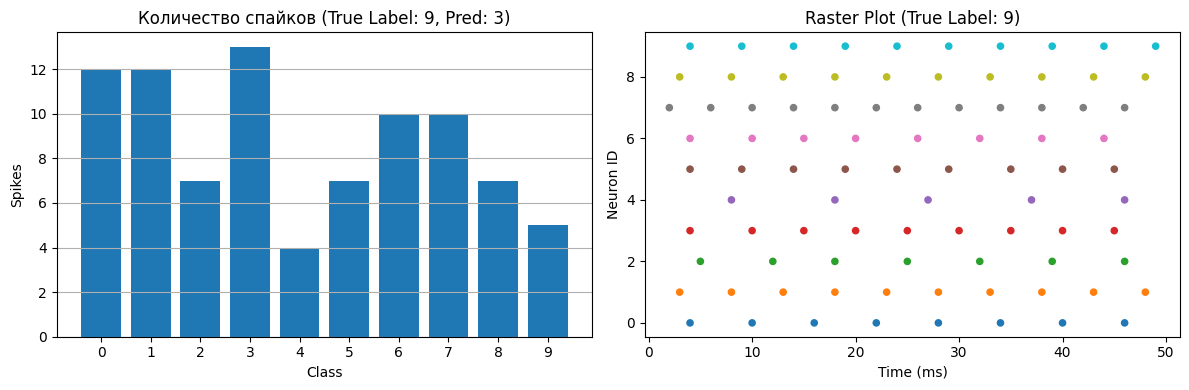


Final Accuracy: 0.3543


In [14]:
image, label = test_dataset[0]
image = image.unsqueeze(0).to(device)

rates = population_encode(image)
spikes = generate_poisson_spikes(rates, SIM_TIME)

v = torch.full((1, OUTPUT_NEURONS), -65.0, device=device)
refractory = torch.zeros((1, OUTPUT_NEURONS), device=device)

spike_times = []
spike_neurons = []

for t in range(SIM_TIME):
    currents = spikes[t] @ weights * 2
    dv = (-(v - v_rest) + r_m * currents) / tau_m
    v = v + dv
    
    fired = (v >= v_thresh).float()
    v = torch.where(fired.bool(), v_reset, v)
    refractory = torch.where(fired.bool(), torch.tensor(tau_ref, device=device), refractory)
        
    in_ref = (refractory > 0).bool()
    v = torch.where(in_ref, v_rest, v)
    refractory = torch.where(in_ref, refractory - 1, refractory)
    
    if fired.any():
        for n in range(OUTPUT_NEURONS):
            if fired[0, n]:
                spike_times.append(t)
                spike_neurons.append(n)


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(10), spike_counts[0].cpu().numpy())
plt.xticks(range(10))
plt.title(f"Количество спайков (True Label: {label}, Pred: {predictions[0].item()})")
plt.xlabel("Class")
plt.ylabel("Spikes")
plt.grid(axis='y')

plt.subplot(1, 2, 2)
if spike_times:
    plt.scatter(spike_times, spike_neurons, s=20, c=spike_neurons, cmap='tab10')
    plt.title(f"Raster Plot (True Label: {label})")
else:
    plt.text(0.5, 0.5, "No spikes!", ha='center', va='center', fontsize=12)
    plt.title("Raster Plot - EMPTY")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron ID")
plt.tight_layout()
plt.show()

print(f"\nFinal Accuracy: {accuracy:.4f}")

#### Видно, что некоторые классы получили меньше спайков, чем другие, это лучший результат, который удалось получить.

## **КАКАЯ ЭТО ОДЕЖДА?**

Loading model from 40-30min.pt...
Device: cuda

Processing: tshirt.png

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



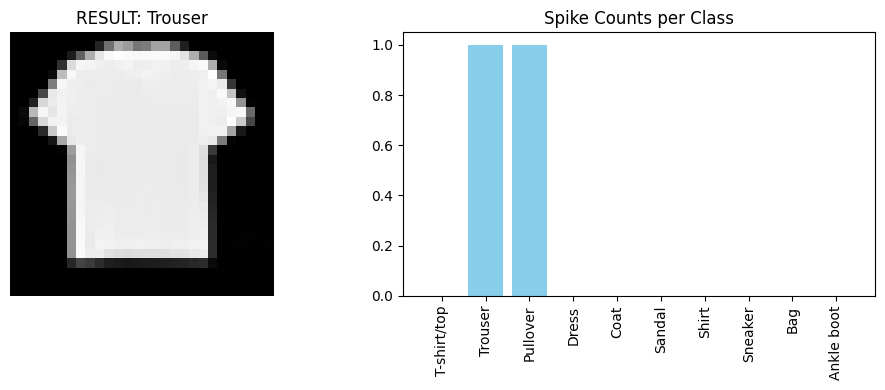


Processing: sneaker.png

Prediction: Dress (Class 3)
Confidence: 2.00% (1/50 spikes)



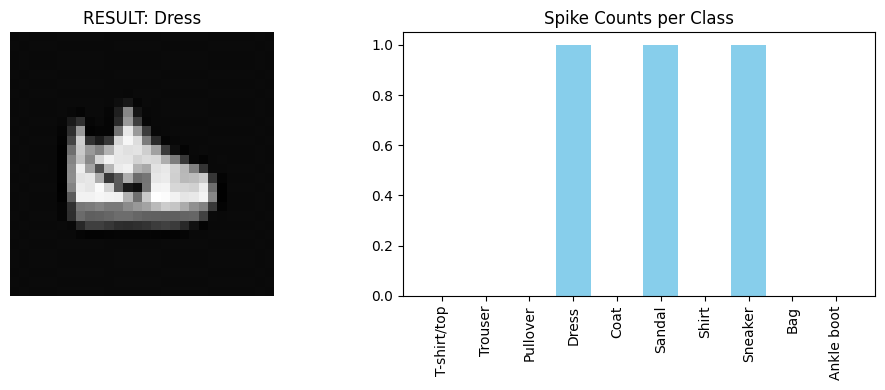


Processing: dress.png

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



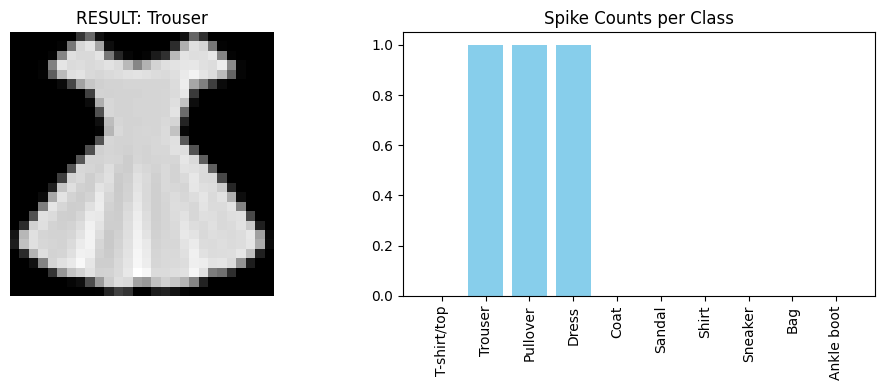


Processing: coat.jpg

Prediction: Pullover (Class 2)
Confidence: 4.00% (2/50 spikes)



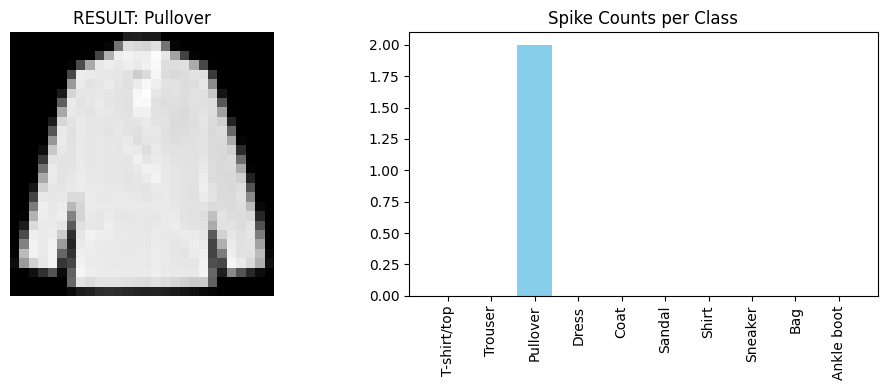


Processing: pullover.jpg

Prediction: Pullover (Class 2)
Confidence: 4.00% (2/50 spikes)



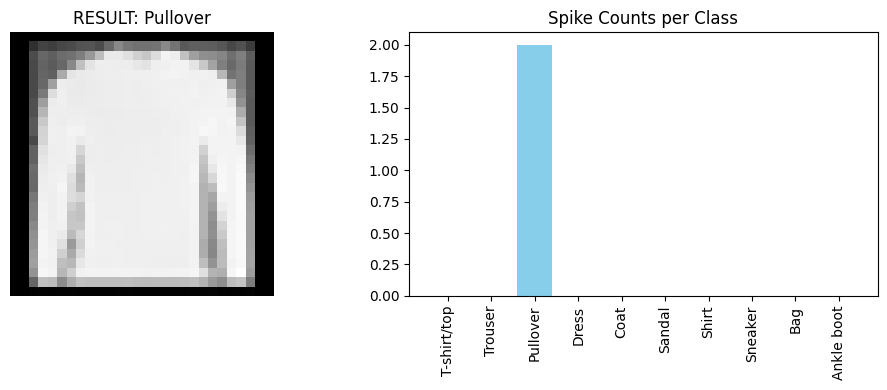


Processing: sandal.jpg

Prediction: Sneaker (Class 7)
Confidence: 2.00% (1/50 spikes)



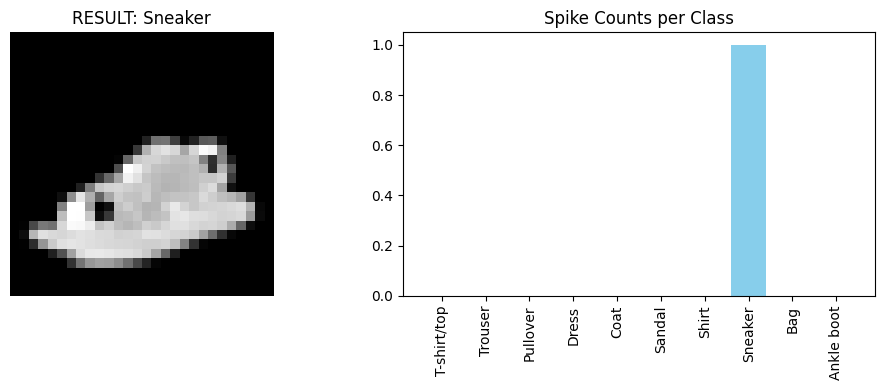


Processing: bag.jpg

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



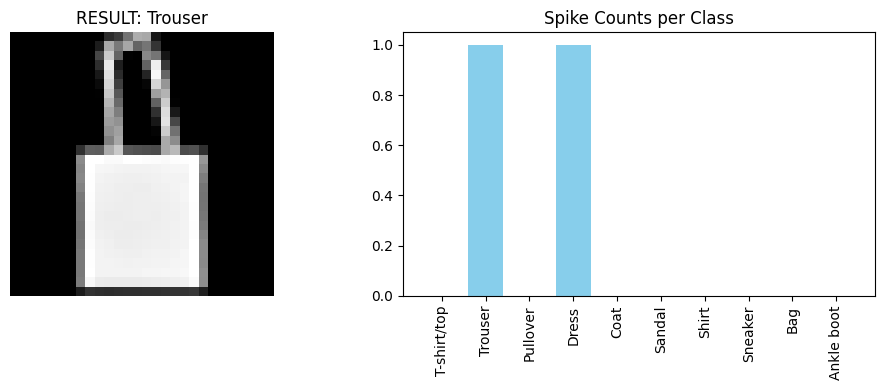


Processing: ankle.jpg

Prediction: T-shirt/top (Class 0)
Confidence: 0.00% (0/50 spikes)



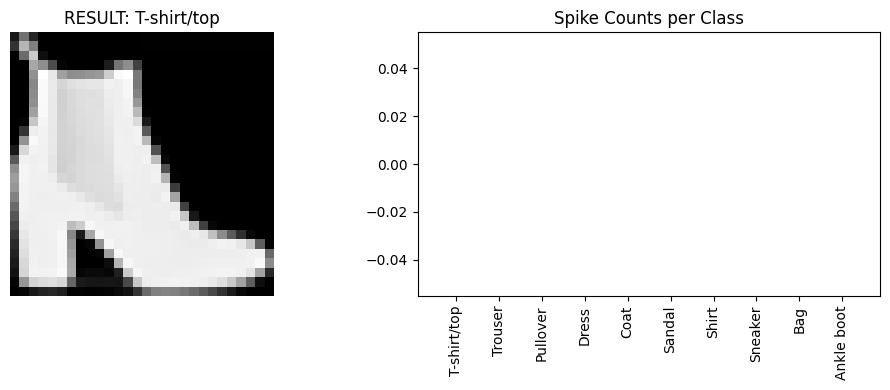


Processing: trouser.png

Prediction: Trouser (Class 1)
Confidence: 2.00% (1/50 spikes)



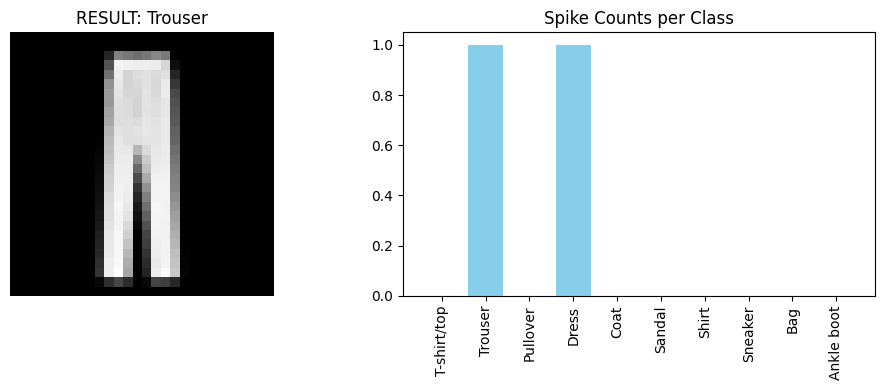


Processing: shirt.png

Prediction: Pullover (Class 2)
Confidence: 2.00% (1/50 spikes)



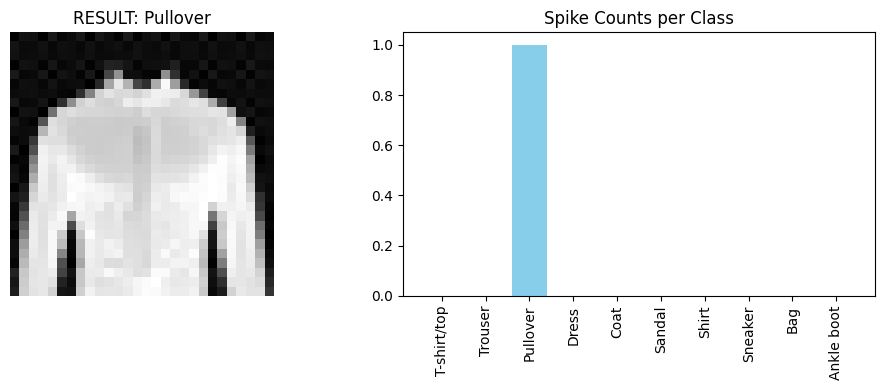

In [15]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import sys
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_PATH = '40-30min.pt'

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Loading model from {MODEL_PATH}...")
if not os.path.exists(MODEL_PATH):
    sys.exit(1)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
weights = checkpoint['weights'].to(DEVICE)
POP_NEURONS = checkpoint['pop_neurons']
SIM_TIME = checkpoint['sim_time']

INPUT_NEURONS = 784 * POP_NEURONS
OUTPUT_NEURONS = 10

print(f"Device: {DEVICE}")

def preprocess_image(path):
    img = Image.open(path).convert('L')
    img = img.resize((28, 28))   
    
    img_array = np.array(img)
    img_array = 255 - img_array          
    img_array = img_array / 255.0 
    
    tensor = torch.FloatTensor(img_array).unsqueeze(0).unsqueeze(0)
    return tensor.to(DEVICE), img_array


def predict(image_path):
    print(f"\nProcessing: {image_path}")
    
    if not os.path.exists(image_path):
        print("Error: Image file not found!")
        return
    
    tensor, img_array = preprocess_image(image_path)
    
    rates = population_encode(tensor)
    
    spikes = generate_poisson_spikes(rates, SIM_TIME)
    
    with torch.no_grad():
        spike_counts = run_lif(spikes, weights)
        prediction = torch.argmax(spike_counts, dim=1).item()
        confidence = spike_counts[0, prediction].item() / SIM_TIME
    
    class_name = CLASS_NAMES[prediction]
    print(f"\n{'='*40}")
    print(f"Prediction: {class_name} (Class {prediction})")
    print(f"Confidence: {confidence:.2%} ({int(confidence*SIM_TIME)}/{SIM_TIME} spikes)")
    print(f"{'='*40}\n")
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img_array, cmap='gray')
    plt.title(f"RESULT: {class_name}")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.bar(CLASS_NAMES, spike_counts[0].cpu().numpy(), color='skyblue')
    plt.xticks(rotation=90)
    plt.title("Spike Counts per Class")
    plt.tight_layout()
    plt.show()
    
predict("tshirt.png")
predict("sneaker.png")
predict("dress.png")
predict("coat.jpg")
predict("pullover.jpg")
predict("sandal.jpg")
predict("bag.jpg")
predict("ankle.jpg")
predict("trouser.png")
predict("shirt.png")

## **РЕЗУЛЬТАТЫ**

### По результатам видно, что модель справляется так себе, но все таки смысл в её действиях есть. По графикам видно, что модель обычно, делает несколько выводов об изображении и выбирает самый первый вариант. 
- ### Например все предметы верхней одежды имееют класс pullover. 
- ### Штаны - либо штаны, либо платье. 
- ### Сапог вообще не был распознан.
- ### Сандаль был распознан как кроссовок.
- ### Кросовок в это время является платьем, сандалем или же КРОССОВКОМ.

### Модель получилась очень неточной, но признаки разума у нее есть. Нужно продолжать изучение параметров для обучения

## **ВЫВОД**

#### В ходе лабораторной работы была обучена спайковая нейронная сеть. Задачей было распознование 10 типов одежды. Сеть с задачей справилась **УДОВЛЕТВОРИТЕЛЬНО**.
#### Для улучшения результатов перебирались значения параметров, таких как: батч, время симуляции, кол-во нейронов на один пиксель, потенциалы
#### Максимальное значение точности, которое удалось достичь это accuracy 0.4.